In [ ]:
#!pip install tensorflow-gpu==2.0.0
#!pip install tensorflow_hub
#pip install tf-nightly
#!pip install tensorflow --user --upgrade
#!pip install keras --user --upgrade

In [3]:
# import the libraries as shown below

from tensorflow.keras.layers import Input, Lambda, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications.resnet50 import ResNet50
#from keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
from tensorflow.keras.models import Sequential
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

In [4]:
from __future__ import absolute_import, division, print_function, unicode_literals

import matplotlib.pylab as plt
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np

In [5]:
import pandas as pd

# Increase precision of presented data for better side-by-side comparison
pd.set_option("display.precision", 8)


In [20]:
print("Version: ", tf.__version__)
print("Hub version: ", hub.__version__)
print("Eager mode: ", tf.executing_eagerly())
print("GPU is", "available" if tf.test.is_gpu_available() else "NOT AVAILABLE")

Version:  2.4.1
Hub version:  0.11.0
Eager mode:  True
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


GPU is NOT AVAILABLE


In [21]:
data_root = '/content/drive/MyDrive/Fish Diseases/Train'

In [22]:
# Create data generator for training and validation

IMAGE_SHAPE = (224, 224)
TRAINING_DATA_DIR = str(data_root)

datagen_kwargs = dict(rescale=1./255, validation_split=.10)
valid_datagen = tf.keras.preprocessing.image.ImageDataGenerator(**datagen_kwargs)
valid_generator = valid_datagen.flow_from_directory(
    TRAINING_DATA_DIR, 
    subset="validation", 
    shuffle=True,
    target_size=IMAGE_SHAPE
)

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(**datagen_kwargs)
train_generator = train_datagen.flow_from_directory(
    TRAINING_DATA_DIR, 
    subset="training", 
    shuffle=True,
    target_size=IMAGE_SHAPE)

Found 102 images belonging to 3 classes.
Found 926 images belonging to 3 classes.


In [23]:
# Learn more about data batches

image_batch_train, label_batch_train = next(iter(train_generator))
print("Image batch shape: ", image_batch_train.shape)
print("Label batch shape: ", label_batch_train.shape)

Image batch shape:  (32, 224, 224, 3)
Label batch shape:  (32, 3)


In [ ]:

# Learn about dataset labels

dataset_labels = sorted(train_generator.class_indices.items(), key=lambda pair:pair[1])
dataset_labels = np.array([key.title() for key, value in dataset_labels])
print(dataset_labels)

['Argulus' 'Epizootic Ulcerative' 'Tail & Fin Rot']


In [24]:

model = tf.keras.Sequential([
  hub.KerasLayer("https://tfhub.dev/google/imagenet/mobilenet_v2_100_224/feature_vector/4", 
                 output_shape=[1280],
                 trainable=False),
  tf.keras.layers.Dropout(0.4),
  tf.keras.layers.Dense(train_generator.num_classes, activation='softmax')
])
model.build([None, 224, 224, 3])

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
keras_layer (KerasLayer)     (None, 1280)              2257984   
_________________________________________________________________
dropout (Dropout)            (None, 1280)              0         
_________________________________________________________________
dense (Dense)                (None, 3)                 3843      
Total params: 2,261,827
Trainable params: 3,843
Non-trainable params: 2,257,984
_________________________________________________________________


In [ ]:
model.compile(
  optimizer=tf.keras.optimizers.Adam(),
  loss='categorical_crossentropy',
  metrics=['acc'])

In [ ]:
# Run model training

steps_per_epoch = np.ceil(train_generator.samples/train_generator.batch_size)
val_steps_per_epoch = np.ceil(valid_generator.samples/valid_generator.batch_size)

hist = model.fit(
    train_generator, 
    epochs=5,
    verbose=1,
    steps_per_epoch=steps_per_epoch,
    validation_data=valid_generator,
    validation_steps=val_steps_per_epoch).history

Epoch 1/5
29/29 [==============================] - 395s 13s/step - loss: 1.4288 - acc: 0.5123 - val_loss: 0.6648 - val_acc: 0.6569
Epoch 2/5
29/29 [==============================] - 41s 1s/step - loss: 0.3875 - acc: 0.8291 - val_loss: 0.3885 - val_acc: 0.7941
Epoch 3/5
29/29 [==============================] - 41s 1s/step - loss: 0.2683 - acc: 0.9049 - val_loss: 0.2554 - val_acc: 0.8922
Epoch 4/5
29/29 [==============================] - 41s 1s/step - loss: 0.1845 - acc: 0.9310 - val_loss: 0.1778 - val_acc: 0.9608
Epoch 5/5
29/29 [==============================] - 41s 1s/step - loss: 0.1570 - acc: 0.9410 - val_loss: 0.1629 - val_acc: 0.9608


In [ ]:

# Measure accuracy and loss after training

final_loss, final_accuracy = model.evaluate(valid_generator, steps = val_steps_per_epoch)

4/4 [==============================] - 4s 902ms/step - loss: 0.1629 - acc: 0.9608


In [ ]:

print("Final loss: {:.2f}%".format(final_loss))
print("Final accuracy: {:.2f}%".format(final_accuracy * 100))

Final loss: 0.16%
Final accuracy: 96.08%


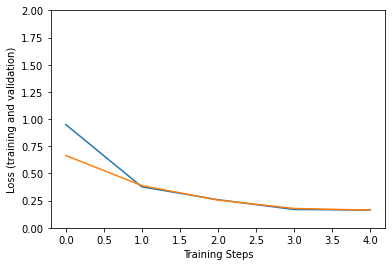

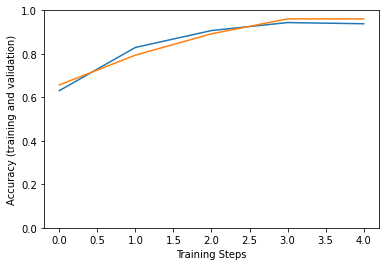

In [ ]:
# Visualize training process

plt.figure()
plt.ylabel("Loss (training and validation)")
plt.xlabel("Training Steps")
plt.ylim([0,2])
plt.plot(hist["loss"])
plt.plot(hist["val_loss"])

plt.figure()
plt.ylabel("Accuracy (training and validation)")
plt.xlabel("Training Steps")
plt.ylim([0,1])
plt.plot(hist["acc"])
plt.plot(hist["val_acc"])

In [ ]:
from tensorflow.keras.models import load_model
model.save('fish_disease_detection.h5')

In [ ]:
!mkdir -p saved_model
model.save('saved_model/my_model') 

INFO:tensorflow:Assets written to: saved_model/my_model/assets


INFO:tensorflow:Assets written to: saved_model/my_model/assets


In [1]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

In [6]:
my_reloaded_model = tf.keras.models.load_model(('/content/drive/MyDrive/Fish Diseases/fish_disease_detection.h5'),custom_objects={'KerasLayer':hub.KerasLayer})

In [7]:
img=image.load_img('/content/drive/MyDrive/Fish Diseases/Test/Argulus/argulus (2).jpg',target_size=(224,224))

In [8]:
x=image.img_to_array(img)
x

array([[[160., 160., 160.],
        [160., 160., 160.],
        [161., 161., 161.],
        ...,
        [ 62.,  63.,  57.],
        [ 61.,  62.,  57.],
        [ 64.,  65.,  60.]],

       [[160., 160., 160.],
        [160., 160., 160.],
        [160., 160., 160.],
        ...,
        [ 68.,  69.,  63.],
        [ 64.,  65.,  59.],
        [ 62.,  63.,  58.]],

       [[159., 159., 159.],
        [160., 160., 160.],
        [160., 160., 160.],
        ...,
        [ 73.,  74.,  66.],
        [ 69.,  70.,  64.],
        [ 64.,  65.,  59.]],

       ...,

       [[109.,  82.,  55.],
        [109.,  81.,  57.],
        [108.,  80.,  58.],
        ...,
        [162., 166., 167.],
        [162., 166., 169.],
        [162., 166., 169.]],

       [[109.,  82.,  55.],
        [110.,  82.,  58.],
        [109.,  81.,  59.],
        ...,
        [164., 165., 167.],
        [164., 165., 169.],
        [164., 165., 169.]],

       [[108.,  81.,  54.],
        [108.,  80.,  56.],
        [108.,  

In [9]:
x.shape

(224, 224, 3)

In [10]:
x=x/255

In [11]:
x=np.expand_dims(x,axis=0)
img_data=preprocess_input(x)
img_data.shape

(1, 224, 224, 3)

In [13]:
my_reloaded_model.predict(img_data)

array([[0.88391465, 0.00309156, 0.11299382]], dtype=float32)

In [15]:
a=np.argmax(my_reloaded_model.predict(img_data), axis=1)

In [16]:
a

array([0])

In [19]:
a==0

array([ True])

In [ ]:
# Load SavedModel

flowers_model = hub.load(FLOWERS_SAVED_MODEL)
print(flowers_model)

<tensorflow.python.saved_model.load.Loader._recreate_base_user_object.<locals>._UserObject object at 0x7f41b5d1ea58>


In [ ]:
# Get images and labels batch from validation dataset generator

val_image_batch, val_label_batch = next(iter(valid_generator))
true_label_ids = np.argmax(val_label_batch, axis=-1)

print("Validation batch shape:", val_image_batch.shape)

/usr/local/lib/python3.6/dist-packages/PIL/Image.py:932: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  "Palette images with Transparency expressed in bytes should be "


Validation batch shape: (27, 224, 224, 3)


In [ ]:

tf_model_predictions = flowers_model(val_image_batch)
print("Prediction results shape:", tf_model_predictions.shape)

Prediction results shape: (27, 2)


In [ ]:
# Convert prediction results to Pandas dataframe, for better visualization

tf_pred_dataframe = pd.DataFrame(tf_model_predictions.numpy())
tf_pred_dataframe.columns = dataset_labels

print("Prediction results for the first elements")
tf_pred_dataframe.head()

Prediction results for the first elements


,Angry_Birds,Birds
0,0.94123381,0.05876620
1,0.19328074,0.80671924
2,0.97550583,0.02449412
3,0.95260727,0.04739276
4,0.96247911,0.03752087


In [ ]:
predicted_ids = np.argmax(tf_model_predictions, axis=-1)
predicted_labels = dataset_labels[predicted_ids]

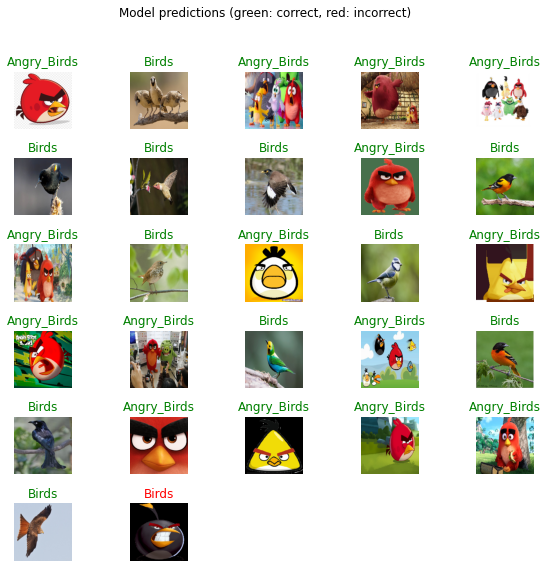

In [ ]:
# Print images batch and labels predictions

plt.figure(figsize=(10,9))
plt.subplots_adjust(hspace=0.5)
for n in range(27):
  plt.subplot(6,5,n+1)
  plt.imshow(val_image_batch[n])
  color = "green" if predicted_ids[n] == true_label_ids[n] else "red"
  plt.title(predicted_labels[n].title(), color=color)
  plt.axis('off')
_ = plt.suptitle("Model predictions (green: correct, red: incorrect)")

In [ ]:

!mkdir "tflite_models"

mkdir: cannot create directory ‘tflite_models’: File exists


In [ ]:
TFLITE_MODEL = "tflite_models/flowers.tflite"
TFLITE_QUANT_MODEL = "tflite_models/flowers_quant.tflite"

In [ ]:
# Get the concrete function from the Keras model.
run_model = tf.function(lambda x : flowers_model(x))

# Save the concrete function.
concrete_func = run_model.get_concrete_function(
    tf.TensorSpec(model.inputs[0].shape, model.inputs[0].dtype)
)

# Convert the model
converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete_func])
converted_tflite_model = converter.convert()
open(TFLITE_MODEL, "wb").write(converted_tflite_model)

# Convert the model to quantized version with post-training quantization
converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete_func])
converter.optimizations = [tf.lite.Optimize.OPTIMIZE_FOR_SIZE]
tflite_quant_model = converter.convert()
open(TFLITE_QUANT_MODEL, "wb").write(tflite_quant_model)

print("TFLite models and their sizes:")
!ls "tflite_models" -lh

TFLite models and their sizes:
total 12M
-rw-r--r-- 1 root root 2.7M Jan 31 11:46 flowers_quant.tflite
-rw-r--r-- 1 root root 8.6M Jan 31 11:46 flowers.tflite
-rw-r--r-- 1 root root   17 Jan 31 09:57 labels.txt


In [ ]:
# Load TFLite model and see some details about input/output

tflite_interpreter = tf.lite.Interpreter(model_path=TFLITE_MODEL)

input_details = tflite_interpreter.get_input_details()
output_details = tflite_interpreter.get_output_details()

print("== Input details ==")
print("name:", input_details[0]['name'])
print("shape:", input_details[0]['shape'])
print("type:", input_details[0]['dtype'])

print("\n== Output details ==")
print("name:", output_details[0]['name'])
print("shape:", output_details[0]['shape'])
print("type:", output_details[0]['dtype'])

== Input details ==
name: x
shape: [1 1 1 1]
type: <class 'numpy.float32'>

== Output details ==
name: Identity
shape: [1 2]
type: <class 'numpy.float32'>


In [ ]:
tflite_interpreter.resize_tensor_input(input_details[0]['index'], (27, 224, 224, 3)) #batch size 27
tflite_interpreter.resize_tensor_input(output_details[0]['index'], (32, 2))   # output labels 2
tflite_interpreter.allocate_tensors()

input_details = tflite_interpreter.get_input_details()
output_details = tflite_interpreter.get_output_details()

print("== Input details ==")
print("name:", input_details[0]['name'])
print("shape:", input_details[0]['shape'])
print("type:", input_details[0]['dtype'])

print("\n== Output details ==")
print("name:", output_details[0]['name'])
print("shape:", output_details[0]['shape'])

== Input details ==
name: x
shape: [ 27 224 224   3]
type: <class 'numpy.float32'>

== Output details ==
name: Identity
shape: [27  2]


In [ ]:
tflite_interpreter.set_tensor(input_details[0]['index'], val_image_batch)

tflite_interpreter.invoke()

tflite_model_predictions = tflite_interpreter.get_tensor(output_details[0]['index'])
print("Prediction results shape:", tflite_model_predictions.shape)

Prediction results shape: (27, 2)


In [ ]:
# Convert prediction results to Pandas dataframe, for better visualization

tflite_pred_dataframe = pd.DataFrame(tflite_model_predictions)
tflite_pred_dataframe.columns = dataset_labels

print("TFLite prediction results for the first elements")
tflite_pred_dataframe.head()

TFLite prediction results for the first elements


,Angry_Birds,Birds
0,0.94123352,0.05876655
1,0.19328047,0.80671954
2,0.97550583,0.02449412
3,0.95260733,0.04739260
4,0.96247888,0.03752108


In [ ]:
# Load quantized TFLite model
tflite_interpreter_quant = tf.lite.Interpreter(model_path=TFLITE_QUANT_MODEL)

# Learn about its input and output details
input_details = tflite_interpreter_quant.get_input_details()
output_details = tflite_interpreter_quant.get_output_details()

# Resize input and output tensors to handle batch of 27 images & 2 labels
tflite_interpreter_quant.resize_tensor_input(input_details[0]['index'], (27, 224, 224, 3))
tflite_interpreter_quant.resize_tensor_input(output_details[0]['index'], (32, 2))
tflite_interpreter_quant.allocate_tensors()

input_details = tflite_interpreter_quant.get_input_details()
output_details = tflite_interpreter_quant.get_output_details()

print("== Input details ==")
print("name:", input_details[0]['name'])
print("shape:", input_details[0]['shape'])
print("type:", input_details[0]['dtype'])

print("\n== Output details ==")
print("name:", output_details[0]['name'])
print("shape:", output_details[0]['shape'])
print("type:", output_details[0]['dtype'])

# Run inference
tflite_interpreter_quant.set_tensor(input_details[0]['index'], val_image_batch)

tflite_interpreter_quant.invoke()

tflite_q_model_predictions = tflite_interpreter_quant.get_tensor(output_details[0]['index'])
print("\nPrediction results shape:", tflite_q_model_predictions.shape)

== Input details ==
name: x
shape: [ 27 224 224   3]
type: <class 'numpy.float32'>

== Output details ==
name: Identity
shape: [27  2]
type: <class 'numpy.float32'>

Prediction results shape: (27, 2)


In [ ]:
# Convert prediction results to Pandas dataframe, for better visualization

tflite_q_pred_dataframe = pd.DataFrame(tflite_q_model_predictions)
tflite_q_pred_dataframe.columns = dataset_labels

print("Quantized TFLite model prediction results for the first elements")
tflite_q_pred_dataframe.head()

Quantized TFLite model prediction results for the first elements


,Angry_Birds,Birds
0,0.93459523,0.06540480
1,0.19727160,0.80272841
2,0.97202402,0.02797602
3,0.95341212,0.04658784
4,0.96106923,0.03893079


In [ ]:
# Concatenate results from all models

all_models_dataframe = pd.concat([tf_pred_dataframe, 
                                  tflite_pred_dataframe, 
                                  tflite_q_pred_dataframe], 
                                 keys=['TF Model', 'TFLite', 'TFLite quantized'],
                                 axis='columns')
all_models_dataframe.head()

TF Model                  TFLite             TFLite quantized            
  Angry_Birds       Birds Angry_Birds       Birds      Angry_Birds       Birds
0  0.94123381  0.05876620  0.94123352  0.05876655       0.93459523  0.06540480
1  0.19328074  0.80671924  0.19328047  0.80671954       0.19727160  0.80272841
2  0.97550583  0.02449412  0.97550583  0.02449412       0.97202402  0.02797602
3  0.95260727  0.04739276  0.95260733  0.04739260       0.95341212  0.04658784
4  0.96247911  0.03752087  0.96247888  0.03752108       0.96106923  0.03893079

In [ ]:
# Swap columns to hava side by side comparison

all_models_dataframe = all_models_dataframe.swaplevel(axis='columns')[tflite_pred_dataframe.columns]
all_models_dataframe.head()

Angry_Birds              ...       Birds                 
     TF Model      TFLite  ...      TFLite TFLite quantized
0  0.94123381  0.94123352  ...  0.05876655       0.06540480
1  0.19328074  0.19328047  ...  0.80671954       0.80272841
2  0.97550583  0.97550583  ...  0.02449412       0.02797602
3  0.95260727  0.95260733  ...  0.04739260       0.04658784
4  0.96247911  0.96247888  ...  0.03752108       0.03893079

[5 rows x 6 columns]

In [ ]:

# Highlight TFLite models predictions that are different from original model

def highlight_diff(data, color='yellow'):
    attr = 'background-color: {}'.format(color)
    other = data.xs('TF Model', axis='columns', level=-1)
    return pd.DataFrame(np.where(data.ne(other, level=0), attr, ''),
                        index=data.index, columns=data.columns)

all_models_dataframe.style.apply(highlight_diff, axis=None)

In [ ]:

# Concatenation of argmax and max value for each row
def max_values_only(data):
  argmax_col = np.argmax(data, axis=1).reshape(-1, 1)
  max_col = np.max(data, axis=1).reshape(-1, 1)
  return np.concatenate([argmax_col, max_col], axis=1)

# Build simplified prediction tables
tf_model_pred_simplified = max_values_only(tf_model_predictions)
tflite_model_pred_simplified = max_values_only(tflite_model_predictions)
tflite_q_model_pred_simplified = max_values_only(tflite_q_model_predictions)

In [ ]:
# Build DataFrames and present example
columns_names = ["Label_id", "Confidence"]
tf_model_simple_dataframe = pd.DataFrame(tf_model_pred_simplified)
tf_model_simple_dataframe.columns = columns_names

tflite_model_simple_dataframe = pd.DataFrame(tflite_model_pred_simplified)
tflite_model_simple_dataframe.columns = columns_names

tflite_q_model_simple_dataframe = pd.DataFrame(tflite_q_model_pred_simplified)
tflite_q_model_simple_dataframe.columns = columns_names

tf_model_simple_dataframe.head()

,Label_id,Confidence
0,0.0,0.94123381
1,1.0,0.80671924
2,0.0,0.97550583
3,0.0,0.95260727
4,0.0,0.96247911


In [ ]:
# Concatenate results from all models
all_models_simple_dataframe = pd.concat([tf_model_simple_dataframe, 
                                         tflite_model_simple_dataframe, 
                                         tflite_q_model_simple_dataframe], 
                                        keys=['TF Model', 'TFLite', 'TFLite quantized'],
                                        axis='columns')

# Swap columns for side-by-side comparison
all_models_simple_dataframe = all_models_simple_dataframe.swaplevel(axis='columns')[tf_model_simple_dataframe.columns]

# Highlight differences
all_models_simple_dataframe.style.apply(highlight_diff, axis=None)

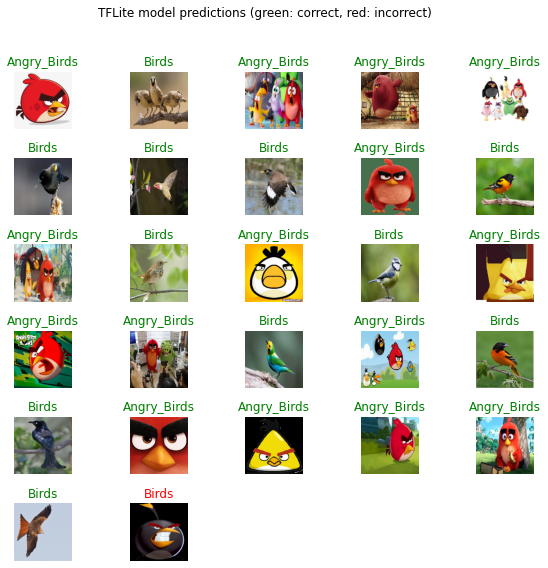

In [ ]:
# Print images batch and labels predictions for TFLite Model

tflite_predicted_ids = np.argmax(tflite_model_predictions, axis=-1)
tflite_predicted_labels = dataset_labels[tflite_predicted_ids]
tflite_label_id = np.argmax(val_label_batch, axis=-1)

plt.figure(figsize=(10,9))
plt.subplots_adjust(hspace=0.5)
for n in range(27):
  plt.subplot(6,5,n+1)
  plt.imshow(val_image_batch[n])
  color = "green" if tflite_predicted_ids[n] == true_label_ids[n] else "red"
  plt.title(tflite_predicted_labels[n].title(), color=color)
  plt.axis('off')
_ = plt.suptitle("TFLite model predictions (green: correct, red: incorrect)")

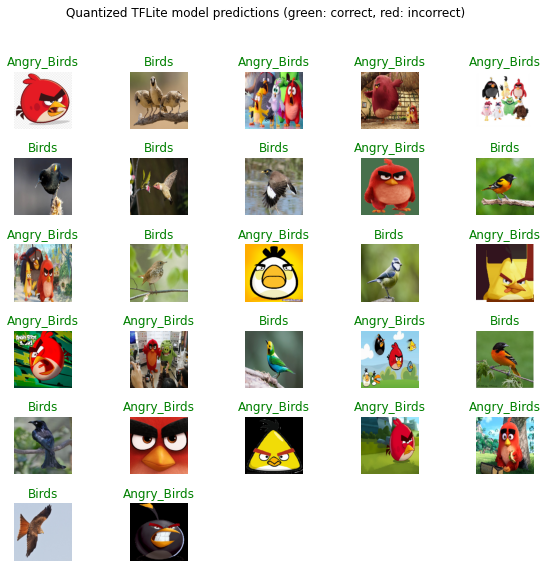

In [ ]:
# Print images batch and labels predictions for TFLite Model

tflite_q_predicted_ids = np.argmax(tflite_q_model_predictions, axis=-1)
tflite_q_predicted_labels = dataset_labels[tflite_q_predicted_ids]
tflite_q_label_id = np.argmax(val_label_batch, axis=-1)

plt.figure(figsize=(10,9))
plt.subplots_adjust(hspace=0.5)
for n in range(27):
  plt.subplot(6,5,n+1)
  plt.imshow(val_image_batch[n])
  color = "green" if tflite_q_predicted_ids[n] == true_label_ids[n] else "red"
  plt.title(tflite_q_predicted_labels[n].title(), color=color)
  plt.axis('off')
_ = plt.suptitle("Quantized TFLite model predictions (green: correct, red: incorrect)")

In [ ]:
from PIL import Image

In [ ]:
VAL_BATCH_DIR = "validation_batch"

In [ ]:

!mkdir {VAL_BATCH_DIR}

mkdir: cannot create directory ‘validation_batch’: File exists


In [ ]:
# Export batch to *.jpg files with specific naming convention.
# Make sure they are exported in the full quality, otherwise the inference
# process will return different results. 

for n in range(27):
  filename = "n{:0.0f}_true{:0.0f}_pred{:0.0f}.jpg".format(
      n,
      true_label_ids[n],
      tflite_model_pred_simplified[n][0]
  )
  img_arr = np.copy(val_image_batch[n])
  img_arr *= 255
  img_arr = img_arr.astype("uint8")
  img11 = Image.fromarray(img_arr, 'RGB')
  img11.save("{}/{}".format(VAL_BATCH_DIR, filename), "JPEG", quality=100)

In [ ]:

!tar -zcvf {VAL_BATCH_DIR}.tar.gz {VAL_BATCH_DIR}

validation_batch/
validation_batch/n7_true1_pred1.jpg
validation_batch/n26_true0_pred0.jpg
validation_batch/n2_true0_pred0.jpg
validation_batch/n20_true0_pred0.jpg
validation_batch/n11_true0_pred0.jpg
validation_batch/n13_true1_pred1.jpg
validation_batch/n8_true0_pred0.jpg
validation_batch/n0_true1_pred1.jpg
validation_batch/n1_true1_pred1.jpg
validation_batch/n15_true1_pred1.jpg
validation_batch/n1_true0_pred0.jpg
validation_batch/n17_true1_pred1.jpg
validation_batch/n4_true0_pred0.jpg
validation_batch/n9_true1_pred1.jpg
validation_batch/n3_true0_pred0.jpg
validation_batch/n5_true0_pred0.jpg
validation_batch/n14_true0_pred0.jpg
validation_batch/n17_true0_pred0.jpg
validation_batch/n19_true0_pred0.jpg
validation_batch/n21_true0_pred0.jpg
validation_batch/n25_true1_pred1.jpg
validation_batch/n8_true1_pred1.jpg
validation_batch/n14_true1_pred1.jpg
validation_batch/n5_true1_pred1.jpg
validation_batch/n6_true0_pred0.jpg
validation_batch/n20_true1_pred1.jpg
validation_batch/n24_true0_pred0.

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import ELU


In [ ]:
import numpy as np
import tensorflow as tf

# Load the TFLite model and allocate tensors.
interpreter = tf.lite.Interpreter(model_path="/content/tflite_models/flowers.tflite")
interpreter.allocate_tensors()

# Get input and output tensors.
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Test the model on random input data.
input_shape = input_details[0]['shape']
input_data = np.array(np.random.random_sample(input_shape), dtype=np.float32)
interpreter.set_tensor(input_details[0]['index'], input_data)

interpreter.invoke()

# The function `get_tensor()` returns a copy of the tensor data.
# Use `tensor()` in order to get a pointer to the tensor.
output_data = interpreter.get_tensor(output_details[0]['index'])
print(output_data)

RuntimeError: ignored

In [ ]:
import cv2
img=cv2.imread('/content/drive/MyDrive/Colab Notebooks/Images/angry_birds/angry_birds (1).jpeg')

In [ ]:
img.shape

In [ ]:
input_details[0]['shape']
#input_details[0]['index']


In [ ]:
new= tf.keras.preprocessing.image_dataset_from_directory(
  img,
  image_size=(224, 224),
  batch_size=27)

In [ ]:

input_data = np(img(input_shape), dtype=np.float32)
input_data.shape

TypeError: ignored

In [ ]:
img = cv2.imread(img)
scalled_raw_img = cv2.resize(img, (32, 32))
img_har = w2d(img,'db1',5)
scalled_img_har = cv2.resize(img_har, (32, 32))

SystemError: ignored